## Adversarial example demo

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from torchvision.models import resnet50, ResNet50_Weights

In [3]:
weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

resnet = resnet50(weights=weights)

In [ ]:
resnet.eval()

In [71]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor, to_pil_image

img = Image.open("../datasets/image_sample/kat.png")
img = pil_to_tensor(img)

img.shape

torch.Size([4, 284, 306])

In [72]:
batch = preprocess(img[:-1]).unsqueeze(0)

In [73]:
prediction = resnet(batch).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print(f"{category_name}: {100 * score:.1f}%")

tabby: 12.4%


In [74]:
idx = np.argsort(prediction.detach().numpy())[::-1]

[weights.meta["categories"][i] for i in idx[:5]]

['tabby', 'tiger cat', 'Egyptian cat', 'mouse', 'lynx']

In [75]:
weights.meta["categories"][1]

'goldfish'

In [76]:
goldfish_idx = 1

Given neural network $f: \mathbb{R}^d \rightarrow \mathcal{C}$, mapping an image to a set of class probabilities, we want to add randomly initialized noise $\epsilon \in \mathbb{R}^d$ to the input $x \in \mathbb{R}^d$, and maximize the classification error with respect to one of the classes $j$, while minimizing the norm of $\epsilon$.
$$
    \epsilon^* = \argmax_\epsilon \;\left([f(x + \epsilon)]_j - ||\epsilon||_2^2 \right)
$$
In the below example, $x$ is an image of a cat, and the $j$-th class is the goldfish class. The pretrained ResNet is frozen, and only $\epsilon$ is optimized. 

The image $x + \epsilon^*$ serves as an adversarial example that looks like an image of a cat, but is predicted to be a goldfish

In [102]:
eps = torch.nn.Parameter(torch.randn_like(batch))

optim = torch.optim.AdamW([eps], lr=0.003, maximize=True, weight_decay=25.2)

for i in range(100):

    pred = resnet(batch + eps).squeeze(0).softmax(0)

    optim.zero_grad()
    pred[goldfish_idx].backward()

    optim.step()

    idx = np.argsort(pred.detach().numpy())[::-1]

    print(i, eps.norm().item(), {weights.meta["categories"][i]: pred.detach().numpy()[i] for i in idx[:5]})

0 358.8432922363281 {'window screen': 0.15291889, 'space heater': 0.056933146, 'computer keyboard': 0.03241142, 'doormat': 0.02070281, 'Persian cat': 0.018264584}
1 331.7225341796875 {'window screen': 0.095400006, 'space heater': 0.06762358, 'computer keyboard': 0.038824458, 'Persian cat': 0.023569904, 'doormat': 0.020977896}
2 306.6564025878906 {'space heater': 0.060193453, 'window screen': 0.05666058, 'computer keyboard': 0.041842148, 'Persian cat': 0.029086659, 'doormat': 0.02292256}
3 283.48663330078125 {'space heater': 0.047930308, 'computer keyboard': 0.036671195, 'Persian cat': 0.036242597, 'window screen': 0.03621361, 'doormat': 0.023033325}
4 262.07110595703125 {'Persian cat': 0.046543743, 'computer keyboard': 0.03133222, 'space heater': 0.03121222, 'window screen': 0.027437532, 'doormat': 0.02257321}
5 242.2764434814453 {'Persian cat': 0.046793338, 'computer keyboard': 0.028571239, 'space heater': 0.021712411, 'window screen': 0.021045318, 'doormat': 0.019093689}
6 223.978713

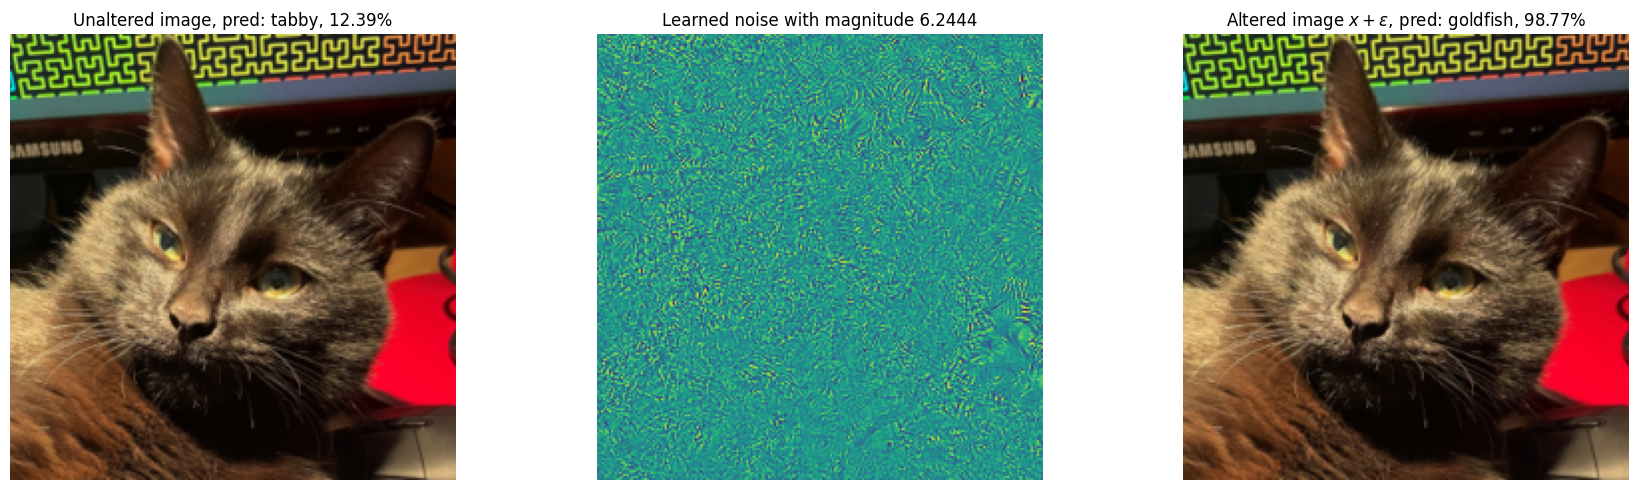

In [130]:
# for reference: torchvision uses this normalization scheme
# normalize = Normalize(mean=[0.485, 0.456, 0.406],
#                         std=[0.229, 0.224, 0.225])
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, -1)
mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, -1)


np_adv_img = (batch + eps).detach().squeeze().permute(1, 2, 0).numpy()
np_img = (batch).detach().squeeze().permute(1, 2, 0).numpy()
np_noise = (eps).detach().squeeze().permute(1, 2, 0).numpy()

# invert normalization and clip bounds between [0, 1]
normalized_adv_img = np.clip(((np_adv_img * std) + mean), 0, 1)
normalized_img = np.clip(((np_img * std) + mean), 0, 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.imshow(normalized_img)
ax1.axis('off')
ax1.set_title(f'Unaltered image, pred: {category_name}, {100*score:.2f}%')

ax2.imshow(eps.detach().squeeze().mean(dim=0).numpy())
ax2.axis('off')
ax2.set_title(f'Learned noise with magnitude {eps.norm():.4f}')

ax3.imshow(normalized_adv_img)
ax3.axis('off')
ax3.set_title(fr'Altered image $x + \epsilon$, pred: {weights.meta["categories"][idx[0]]}, {100*pred.detach().numpy()[idx[0]]:.2f}%')

plt.tight_layout()
plt.show()
